This notebook is a tutorial for using ReX to explain the classification of spectra. I'll be using Raman spectra for this demonstration. I'll be using google colab, but with minor adjustments should be fine for any notebook.

First we need to install ReX. In google colab this may require you to restart the notebook

In [ ]:
# Imports
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

In [59]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [60]:
pip install rex_xai

Note: you may need to restart the kernel to use updated packages.


On google colab, you'll need to mount your drive to get access to the data/model

In [61]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

Define the path to the data/model. Change as needed.

In [62]:
model_path = "../tests/test_data/simple_steel_DNA_model.pt"

Define your model and load in the weights. This is a toy model which is a DNA detector, built with PyTorch.

In [63]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(1, 20, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm1d(20),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=7, stride=3))
        self.layer2 = nn.Sequential(
            nn.Conv1d(20, 40, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm1d(40),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv1d(40, 40, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm1d(40),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=1))
        self.fc1 = nn.Linear(8640, 60)
        self.fc2 = nn.Linear(60, 3)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = F.dropout(out, 0.2)
        out = self.fc2(out)

        return out



In [64]:
# Instantiate
model = ConvNet()

# Put the model onto the device. Best to use GPU if you can
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3️⃣  Load weights
state_dict = torch.load(model_path, map_location="mps")  # or "cuda" if desired
model.load_state_dict(state_dict)

model.eval()  # switch to inference mode
model = model.to(device)

Load the data. This is just a tiny subset of 5 spectra per class, with three classes: no DNA, with DNA and Steel Background

In [65]:
# Load the saved spectra and labels
spectra = np.load('../tests/test_data/ReX_guide_spectra.npy')    # shape (15, 1356)
labels = np.load('../tests/test_data/ReX_guide_labels.npy')      # shape (15,)
common_wn_axis = np.load('../tests/test_data/common_wn_axis.npy')   # shape (1356,)


# Optional: check shapes
print(spectra.shape)  # should be (15, L)
print(labels.shape)   # should be (15,)
print(common_wn_axis.shape)  # should be (L,)


(15, 1356)
(15,)
(1356,)


Visualise the mean spectra across the classes. NOte the data has already been normalised.

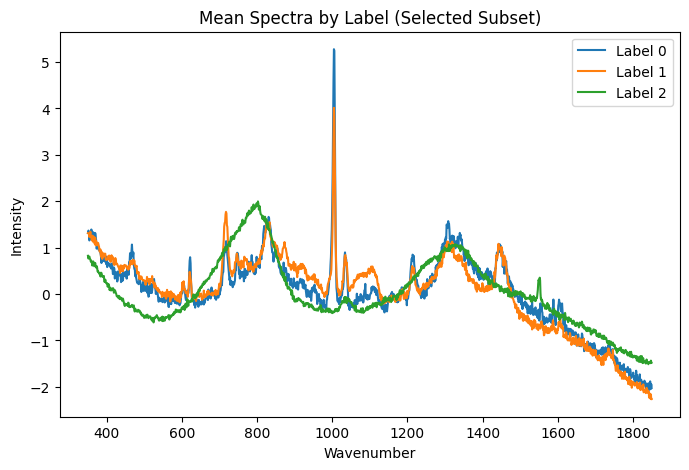

In [66]:
unique_labels = np.unique(labels)

plt.figure(figsize=(8, 5))
for lbl in unique_labels:
    # Select all spectra for this label
    spectra_subset = spectra[labels == lbl]
    # Compute mean spectrum
    mean_spectrum = spectra_subset.mean(axis=0)
    plt.plot(common_wn_axis, mean_spectrum, label=f"Label {lbl}")

plt.xlabel("Wavenumber" if 'common_wn_axis' in locals() else "Wavenumber Index")
plt.ylabel("Intensity")
plt.title("Mean Spectra by Label (Selected Subset)")
plt.legend()
plt.show()

Visualise a single spectrum and return its predicted label, compare to its predicted label

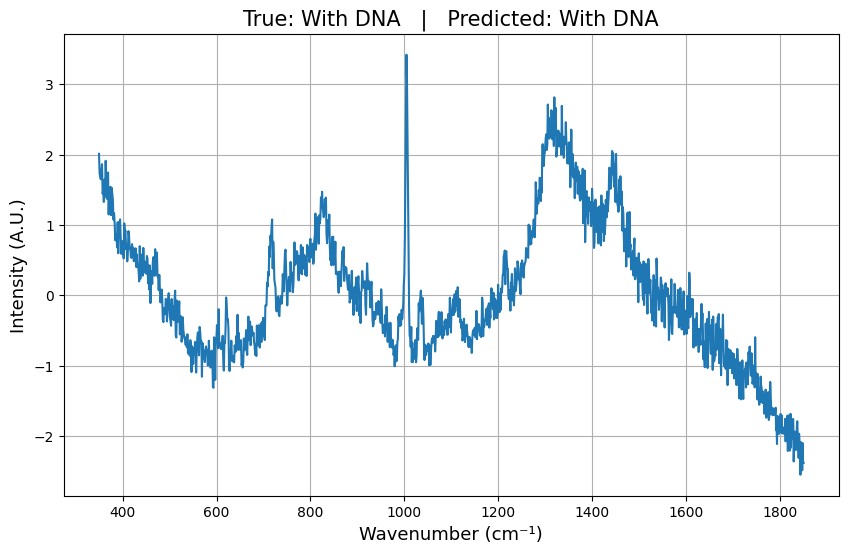

In [67]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ─── 1.  Adjust this index to choose any spectrum ───
idx = 6            # <-- change to 1, 2, … as you wish

spectrum      = spectra[idx]          # 1-D numpy array of length L
true_label_id = int(labels[idx])      # numeric ground-truth class

# Optional: map numeric IDs → readable class names
id2name = {0: "No DNA", 1: "With DNA", 2: "Steel Slide"}   # edit to match your dataset
true_label = id2name.get(true_label_id, f"class {true_label_id}")


model.eval()
# ─── 2.  Run inference on the chosen spectrum ───
x = torch.tensor(spectrum, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # -> [1, 1, L]
with torch.no_grad():
    logits = model(x)
pred_label_id = int(logits.argmax(dim=1).item())
pred_label    = id2name.get(pred_label_id, f"class {pred_label_id}")

# ─── 3.  Plot ───

plt.figure(figsize=(10, 6))
plt.plot(common_wn_axis, spectrum, label=f"Spectrum #{idx}")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)
plt.xlabel("Wavenumber (cm⁻¹)", fontsize=13)
plt.ylabel("Intensity (A.U.)", fontsize=13)
plt.grid(True)
plt.show()


We will now use ReX to find explanations for why the model classifies these spectra the way it does.

In [68]:
# ReX needs to know the model input size

# 1️⃣  Spectrum length
L = spectra.shape[1]          # e.g. 1356 wavenumbers

# 2️⃣  Tell ReX the input shape it should expect. N is the batch size and can be left is for our purposes.
model_shape = ["N", 1, L]

In [69]:
from rex_xai.lib import ReX
print("ReX class:", ReX)

rex = ReX(model, model_shape, device, "spectral") # ReX works on various datatypes. Make sure its set to "spectral" for any spectral types.

ReX class: <class 'rex_xai.lib.ReX'>


First we'll explain a single spectrum

In [70]:
# We chose idx above, that's the spectrum we're explaining

sample = torch.tensor(spectra[idx], dtype=torch.float32) \
                  .unsqueeze(0).to(device)
rex.set_tabular_data(f"sample-{idx}", data=sample)
rex.set_target()
rex.calculate_responsibility()

100%|██████████| 20/20 [00:00<00:00, 43.49it/s]


In [71]:
# We can use rex.stats to get some diagnostics on ReX's performance. If, for instance everything was passing or everything was failing, we would know something is not right.
rex.stats

{'total_passing': 312,
 'total_failing': 906,
 'max_depth_reached': 3,
 'avg_box_size': 93.52291666666666}

In [72]:
# We can extract the responsibility map like this
resp_map = np.asarray(rex.maps.get(0)).squeeze()


Text(0.5, 1.0, 'True: With DNA   |   Predicted: With DNA')

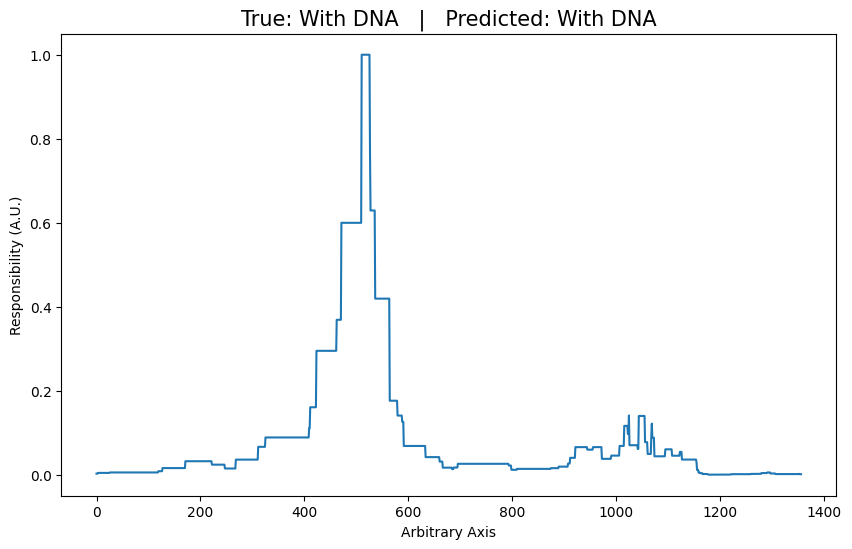

In [73]:
# We can extract the responsibility map like this
resp_map = np.asarray(rex.maps.get(0)).squeeze()


# Then we can plot the raw responsibility map like this
plt.figure(figsize=(10, 6))
plt.plot(resp_map)
plt.xlabel("Arbitrary Axis")
plt.ylabel("Responsibility (A.U.)")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)

This is not very informative as we lack the wavenumber axis, which we'll now add. Note that, like when plotting a spectrum, we wavenumber axis may flip, depending on how the wavenumber axis was defined.

Text(0.5, 1.0, 'True: With DNA   |   Predicted: With DNA')

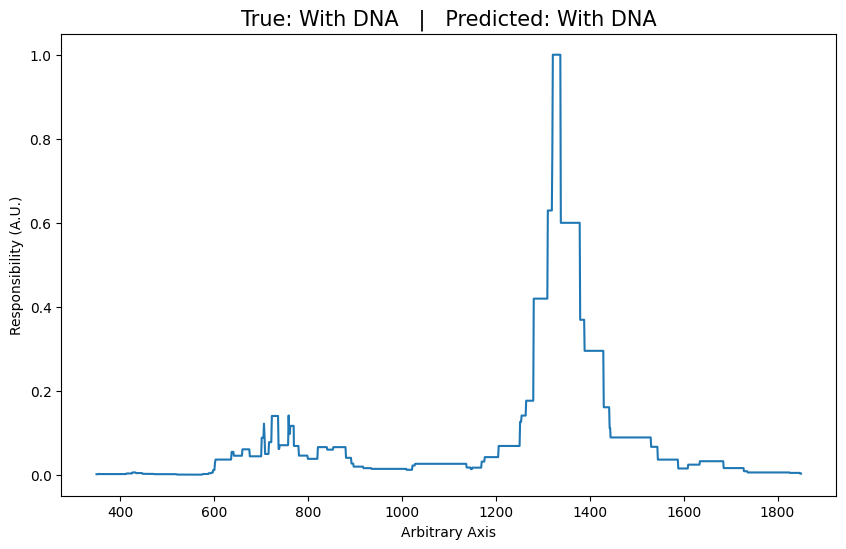

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(common_wn_axis, resp_map)
plt.xlabel("Arbitrary Axis")
plt.ylabel("Responsibility (A.U.)")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)

We can make it even more informative by plotting this as a colourbar and adding the original spectrum on top. Not that the map values themselves are arbitrary, it just reflects how many times the model passed with that wavenumber present, but ReX has a dynamci number of attempts. It is the relative values which matter. For plotting we normalise them.

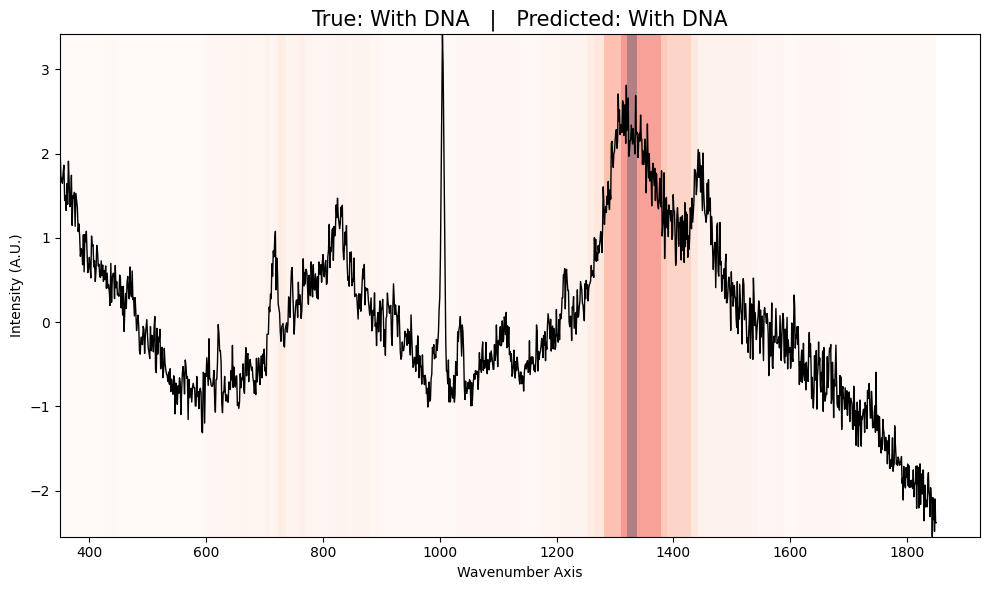

In [75]:
# normalise 0‒1 and reshape for stripe
norm = resp_map / resp_map.max()
heat = norm.reshape(1, -1)  # (1, L)

# build irregular-wavenumber edges so overlay lands at correct x positions
wn = np.asarray(common_wn_axis, dtype=float)
edges = np.empty(len(wn) + 1, dtype=float)
edges[1:-1] = (wn[:-1] + wn[1:]) / 2
edges[0]    = wn[0]  + (wn[1]  - wn[0])  / 2
edges[-1]   = wn[-1] + (wn[-1] - wn[-2]) / 2

fig, ax = plt.subplots(figsize=(10, 6))

# 1) spectrum in black
ax.plot(common_wn_axis, spectrum, color='black', linewidth=1)

# 2) red transparency overlay using the flipped map (pcolormesh respects irregular axis)
ax.pcolormesh(
    edges,
    [spectrum.min(), spectrum.max()],
    heat,
    cmap='Reds',
    shading='auto',
    alpha=0.5
)

ax.set_xlabel("Wavenumber Axis")
ax.set_ylabel("Intensity (A.U.)")
ax.set_title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)
plt.tight_layout()
plt.show()


We can now visually inspect the responsibilty map with its corresponding spectrum. We can repeat this process for any single spectrum in our dataset

Now we will extract a responsibilty map for every spectrum in our dataset and visualise mean spectra and difference spectra between classes. I'm running on the CPU, so each map is a little slow to create.

In [76]:
n = len(spectra)
assert n == len(labels), f"spectra={n}, labels={len(labels)}"

# storage
spectra_by_class   = {0: [], 1: [], 2: []}
resp_maps_by_class = {0: [], 1: [], 2: []}

for i in range(n):
    spec, lbl = spectra[i], int(labels[i])

    # run ReX on this sample
    sample = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(device)
    rex.set_tabular_data(f"sample-{i}", data=sample)
    rex.args.seed = 13
    rex.args.iters = 20
    rex.set_target()
    rex.calculate_responsibility()

    # ── fetch the FIRST map returned ─────────────────────────────
    if not rex.maps.maps:                       # empty dict → hard fail
        raise RuntimeError(f"no map produced for sample {i}")

    resp_map = np.asarray(next(iter(rex.maps.maps.values()))).squeeze()

    # store
    spectra_by_class[lbl].append(spec)
    resp_maps_by_class[lbl].append(resp_map)

print({c: len(v) for c, v in resp_maps_by_class.items()})


100%|██████████| 20/20 [00:00<00:00, 117.88it/s]

{0: 5, 1: 5, 2: 5}


In [77]:
# flip in-place so each map now matches the orientation of common_wn_axis
for cls, maps in resp_maps_by_class.items():
    resp_maps_by_class[cls] = [m[::-1] for m in maps]


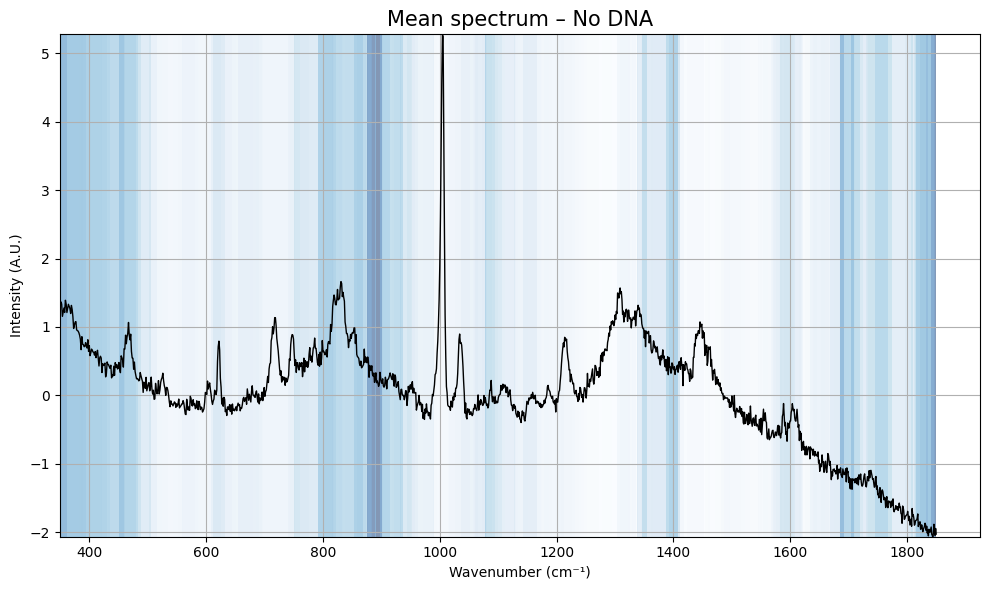

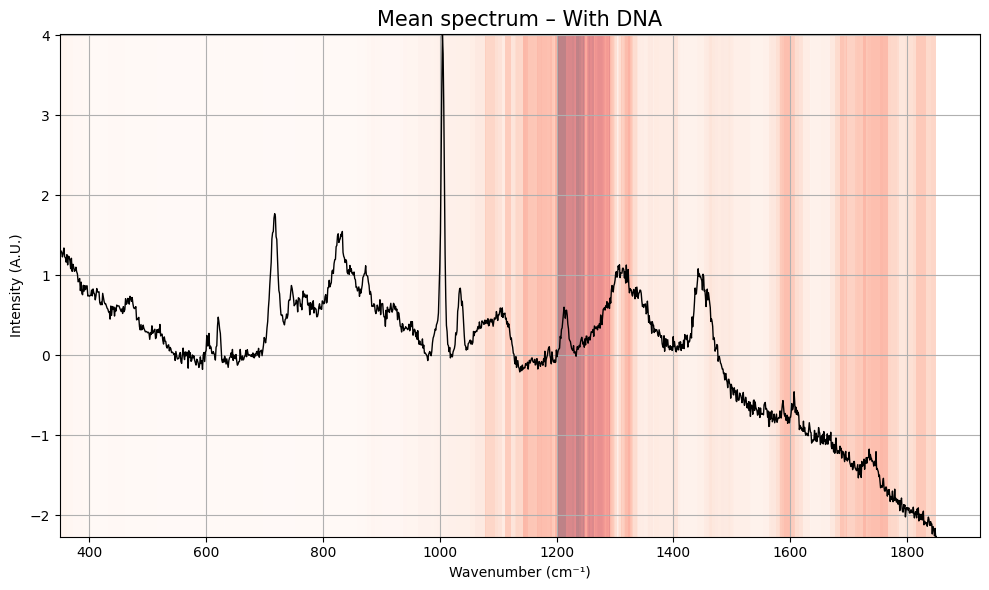

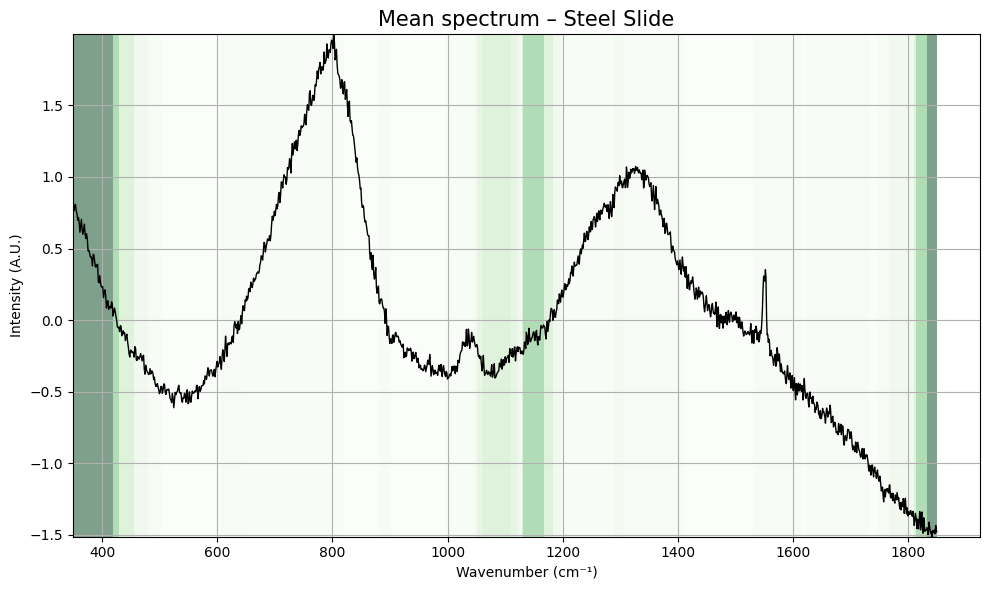

In [78]:
# ────────────────────────── MEAN SPECTRA + STRIPE OVERLAY (all classes) ──────────────────────────
id2name        = {0: "No DNA", 1: "With DNA", 2: "Steel Slide"}
cmap_per_class = {0: "Blues", 1: "Reds",  2: "Greens"}     # overlay colours

def mean_1d(arrays):
    return np.mean(np.stack(arrays, axis=0), axis=0)

for c in (0, 1, 2):
    class_name = id2name.get(c, f"class {c}")

    mspec = mean_1d(spectra_by_class[c])        # mean spectrum
    mmap  = mean_1d(resp_maps_by_class[c])      # mean responsibility map
    norm  = mmap / mmap.max()                   # 0–1

    # build irregular x-edges so pcolormesh honours the true Raman spacing
    wn = common_wn_axis
    edges = np.empty(len(wn) + 1)
    edges[1:-1] = (wn[:-1] + wn[1:]) / 2
    edges[0]    = wn[0]  + (wn[1]  - wn[0])  / 2
    edges[-1]   = wn[-1] + (wn[-1] - wn[-2]) / 2   # axis is descending

    y_edges = [mspec.min(), mspec.max()]       # full vertical span

    plt.figure(figsize=(10, 6))
    plt.plot(wn, mspec, color="black", linewidth=1)

    plt.pcolormesh(
        edges, y_edges, norm.reshape(1, -1),
        cmap=cmap_per_class[c], shading="auto", alpha=0.5
    )

    plt.title(f"Mean spectrum – {class_name}", fontsize=15)
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Intensity (A.U.)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


We can see for class 0, no DNA, is fairly distributed, mostly using information around 900 cm^-1 amongst varous other regions. For class 1, with DNA, the model focuses quite strongly on a peak at about 1210^-1. Let's find out exactly where this peak is:

In [79]:
# mean responsibility map for class 1
mean_resp_map_1 = mean_1d(resp_maps_by_class[1])      # 1-D array length L

# peak value and its index
idx_peak   = int(np.argmax(mean_resp_map_1))
peak_value = mean_resp_map_1[idx_peak]

# corresponding wavenumber
wn_peak = common_wn_axis[idx_peak]

print(f"Peak responsibility = {peak_value:.3g} at wavenumber {wn_peak} cm⁻¹ (index {idx_peak})")


Peak responsibility = 0.547 at wavenumber 1202.9111328125 cm⁻¹ (index 635)


The peak responsibility is atexactly at 1202 cm^-1, though it remains high up to 1250cm^-1. DNA associated peaks have been observed in the literature at ~1245.84 cm^-1, corresponding to: Amide III (collagen); Amide III and other protein groups; n(C-C)-lipids and fatty acids.


But out model has not exavctly learned these features in order to classify. So what's going on? This is a toy model, so it's likely learned spurious correlations - this is useful information as the performance metrics were very high (but they will be if we have overfit our model).


The last class is interesting. The 'Steel Slide' class is actually a 'dustbin' class (i.e. anything not in class 0 or 1). This mostly involved noisy spectra from stainless steel and some other junk. Therefore we expect no features to be leanred. When this hapans, the underlying heuristics of ReX means we see repsonsibility collect at the edges (or in corners for images). When you see this, be suspicious - there is likely no actual information in that class.